In [ ]:
from wrapper import BasicEnvironmentRGB, DomainRandomization
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP, TargetNetwork
from fundamental_variable_discovery import Encoder, Decoder, DoubleAutoencoder
import torch.nn.functional as F
import numpy as np
import torch
import skdim
import time

to_numpy = lambda x: x.cpu().detach().numpy()

gamma = 0.99

def dqn_loss(q_network, q_target, buffer, q_opt, batch_size=512):
    q_target.update()
    obs, action, reward, next_obs, done = buffer.sample(batch_size)
    obs = torch.tensor(obs).float().cuda()
    action = torch.tensor(action).long().cuda()
    reward = torch.tensor(reward).float().cuda()
    next_obs = torch.tensor(next_obs).float().cuda()
    done = torch.tensor(done).float().cuda()
    q_target = reward + gamma * q_target(next_obs).detach().gather(1, torch.argmax(q_network(next_obs).detach(), 1, keepdim=True)).squeeze() * (1 - done)
    q_values = q_network(obs).gather(1, action.unsqueeze(-1)).squeeze()
    q_loss = F.mse_loss(q_target, q_values)
    q_opt.zero_grad()
    q_loss.backward()
    q_opt.step()
    return q_loss

In [ ]:
num_actions = 3
q_network = MLP(6, num_actions, skip_connections=False).cuda()
q_opt = torch.optim.Adam(q_network.parameters(), 3e-4)
dtypes = [np.float32, np.float32, np.float32, np.float32, np.float32]
buffer_shapes = [(6,), (), (), (6,), ()]
dqn_buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=100_000)
q_target = TargetNetwork(q_network, tau=1e-3).cuda()
eps = 1
eps_decay = 0.95
eps_min = 0.1
num_episodes = 500
train_after = 1000
gamma = 0.99

ep_rews = []
q_losses = []
step = 0
ep_rew = 0
ep_rew_ema = None
env = gym.make('Acrobot-v1', render_mode="rgb_array")
for episode in range(num_episodes):
    if episode % 100 == 0:
        print(episode, ep_rew)
    obs, _ = env.reset()
    done = False
    ep_rew = 0
    q_loss_ = []
    while not done:
        step += 1
        if step > train_after:
            obs_tensor = torch.tensor(obs).cuda()
            if np.random.rand() < eps:
                action = np.random.randint(num_actions)
            else:
                action = to_numpy(q_network(obs_tensor).argmax())
            start_time = time.time()
            q_loss = dqn_loss(q_network, q_target, dqn_buffer, q_opt)
            print(f"elapsed, {time.time() - start_time}")
            q_loss_.append(to_numpy(q_loss))
        else:
            action = env.action_space.sample()
        next_obs, reward, term, trunc, _ = env.step(action)
        done = term or trunc
        dqn_buffer.add_sample([obs, action, reward, next_obs, done])
        ep_rew += reward
        obs = next_obs
    ep_rews.append(ep_rew)
    q_losses.append(np.mean(q_loss_))
    eps = max(eps_min, eps * eps_decay)

0 0
100 -188.0
200 -112.0
300 -129.0
400 -100.0


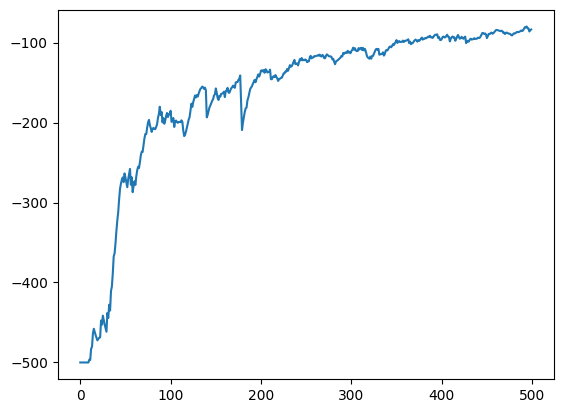

In [3]:
smoothing = 0.9
ep_rew_ema = None
smoothed_rewards = []
for ep_rew in ep_rews:
    if ep_rew_ema is None:
        ep_rew_ema = ep_rew
    else:
        ep_rew_ema = smoothing * ep_rew_ema + (1 - smoothing) * ep_rew
    smoothed_rewards.append(ep_rew_ema)
plt.plot(smoothed_rewards)
plt.savefig("smoothed_ep_rew_baseline.png")
np.save("smoothed_rewards_baseline.npy", np.asarray(smoothed_rewards))

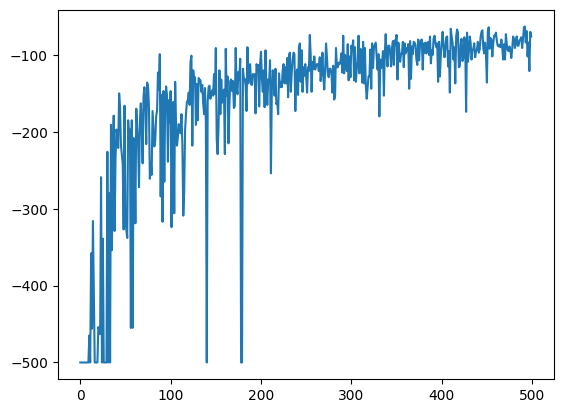

In [4]:
plt.plot(ep_rews)

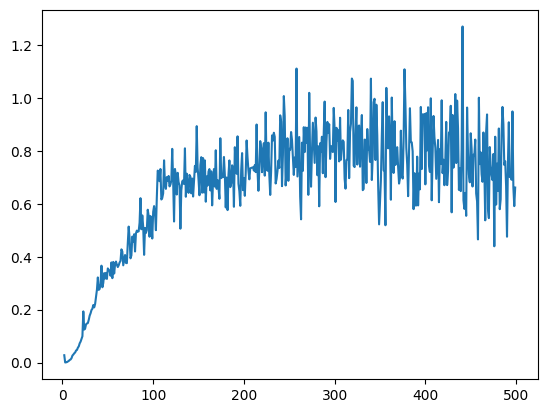

In [5]:
plt.plot(q_losses)